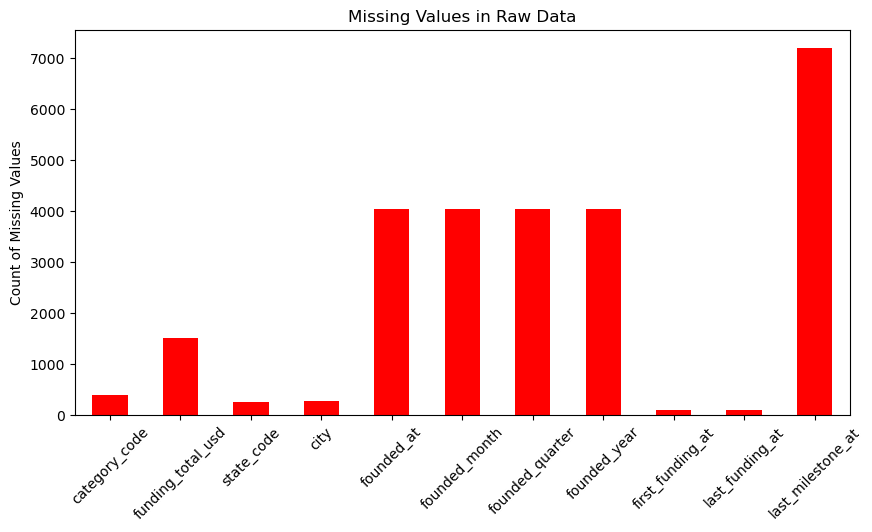

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw dataset
companies = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-companies.csv", encoding='latin1', low_memory=False)

# Count missing values
missing_values = companies.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Keep only columns with missing values

# Plot
plt.figure(figsize=(10, 5))
missing_values.plot(kind='bar', color='red')
plt.title("Missing Values in Raw Data")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()


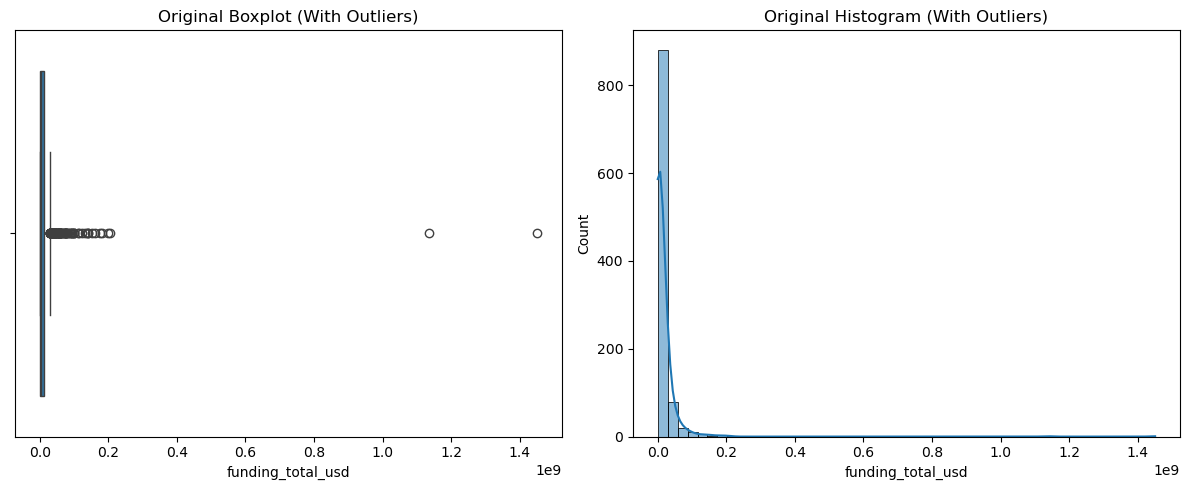

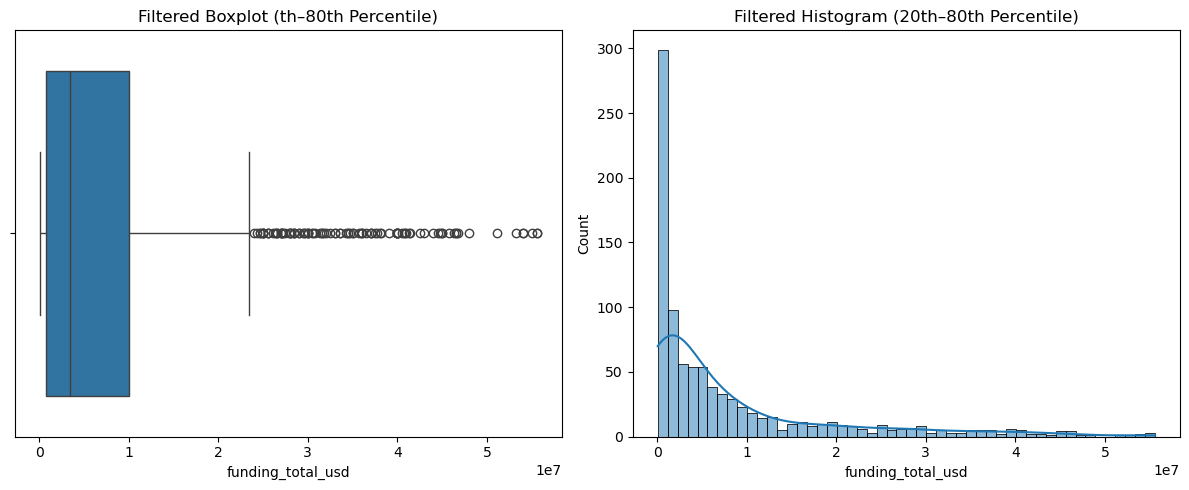

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original dataset
input_file = '/Users/macbook/Downloads/preprocessed_startup_data_2008_v2.csv'
df = pd.read_csv(input_file)

# Plot original distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['funding_total_usd'])
plt.title('Original Boxplot (With Outliers)')

plt.subplot(1, 2, 2)
sns.histplot(df['funding_total_usd'], bins=50, kde=True)
plt.title('Original Histogram (With Outliers)')
plt.tight_layout()
plt.show()

# Remove outliers (20th to 80th percentile)
lower = df['funding_total_usd'].quantile(0.05)
upper = df['funding_total_usd'].quantile(0.95)
df_filtered = df[(df['funding_total_usd'] >= lower) & (df['funding_total_usd'] <= upper)]

# Plot filtered distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_filtered['funding_total_usd'])
plt.title('Filtered Boxplot (th–80th Percentile)')

plt.subplot(1, 2, 2)
sns.histplot(df_filtered['funding_total_usd'], bins=50, kde=True)
plt.title('Filtered Histogram (20th–80th Percentile)')
plt.tight_layout()
plt.show()

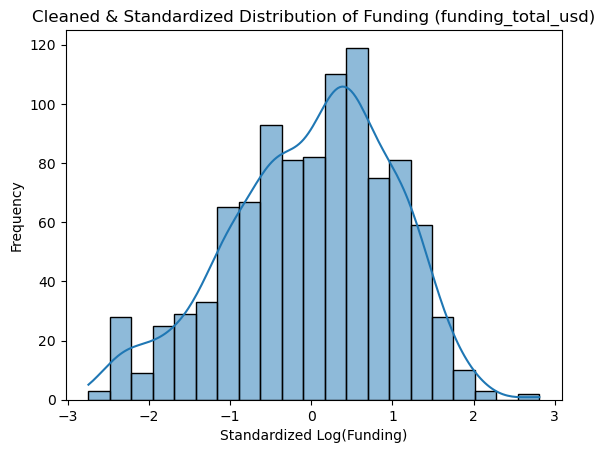

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('/Users/macbook/Downloads/preprocessed_startup_data_2008_v2.csv')

# Step 1: Log-transform 'raised_amount_usd'
raised_log = np.log1p(df['funding_total_usd'])

# Step 2: IQR-based outlier capping
Q1 = raised_log.quantile(0.25)
Q3 = raised_log.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
raised_capped = raised_log.clip(lower, upper)

# Step 3: Standardize the cleaned values
scaler = StandardScaler()
df['funding_total_usd'] = scaler.fit_transform(raised_capped.values.reshape(-1, 1))

# Step 4: Plot the cleaned data
sns.histplot(df['funding_total_usd'], kde=True)
plt.title("Cleaned & Standardized Distribution of Funding (funding_total_usd)")
plt.xlabel("Standardized Log(Funding)")
plt.ylabel("Frequency")
plt.show()
